In [3]:
import pandas as pd
import fastf1
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Video

LOAD DATA

In [4]:
races=pd.read_csv("races_cleaned.csv")
laps=pd.read_csv("laps_clean.csv")
circuits=pd.read_csv("circuits.csv")
drivers_df=pd.read_csv("drivers.csv")
results=pd.read_csv("results_clean.csv")

SELECT RANDOM RACE

In [5]:
race=races.sample(1).iloc[0]

race_id=race['raceId']
year=race['year']
circuit_id=race['circuitId']

# Get the circuit information for the selected race
circuit = circuits[circuits['circuitId'] == circuit_id].iloc[0] 

race_name=race['name']
location=circuit['location']

print(f"selected: {race_name} ({year}) at {location}")

selected: Eifel Grand Prix (2020) at Nürburg


In [6]:
def find_event(year,race_name,location):
    schedule=fastf1.get_event_schedule(year)

    race_name=race_name.lower()
    location=location.lower()

    for _, event in schedule.iterrows():
        event_name=str(event['EventName']).lower()
        event_loc=str(event['Location']).lower()

        if race_name in event_name and location in event_loc:
            return event['EventName']
    
    return None

In [7]:
event_name= find_event(year,race_name, location)

if event_name is None:
    raise ValueError("No matching FastF1 event found.")
print(f"Found event: {event_name}")

req         WARNING 	DEFAULT CACHE ENABLED! (600.15 MB) /home/abhi/.cache/fastf1


Found event: Eifel Grand Prix


LOAD FastF1 TRACK

In [8]:
session= fastf1.get_session(year, event_name, 'R')
session.load()

lap=session.laps.pick_fastest()
tel=lap.get_telemetry().reset_index()

track_x=tel['X']
track_y=tel['Y']
track_len=len(track_x)

core           INFO 	Loading data for Eifel Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 	Driver  7: Ignoring late data f

PREPARE DRIVERS

In [13]:
race_laps = laps[laps['raceId'] == race_id]
drivers = race_laps['driverId'].unique()[:5] # Limit to the first 5 drivers for simplicity

driver_names = {
    row['driverId']: row['surname']
    for _, row in drivers_df.iterrows()
}

print("Drivers in the race:")
for driver_id in drivers:
    print(f"{driver_id}: {driver_names.get(driver_id, 'Unknown')}")

Drivers in the race:
822: Bottas
1: Hamilton
830: Verstappen
844: Leclerc
817: Ricciardo


BUILD LAP

In [10]:
lap_position_map = {}

for lap_num in sorted(race_laps['lap'].unique()):
    lap_data = race_laps[race_laps['lap'] == lap_num]
    lap_data = lap_data.sort_values('position')

    lap_position_map[lap_num] = list(lap_data['driverId'])

ANIMATION SETUP

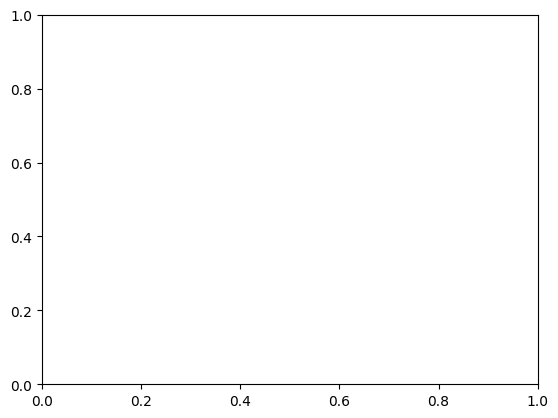

In [11]:
fig, ax = plt.subplots()

FRAMES_PER_LAP = 100
TOTAL_LAPS = len(lap_position_map)
TOTAL_FRAMES = TOTAL_LAPS * FRAMES_PER_LAP

colors = ['blue', 'green', 'red', 'orange', 'purple']
driver_colors = {d: colors[i % len(colors)] for i, d in enumerate(drivers)}

In [12]:
def update(frame):
    ax.clear()
    ax.plot(track_x, track_y, color='black')

    current_lap = frame // FRAMES_PER_LAP + 1
    lap_progress = (frame % FRAMES_PER_LAP) / FRAMES_PER_LAP

    if current_lap not in lap_position_map:
        return

    drivers_order = lap_position_map[current_lap]

    for pos, d in enumerate(drivers_order):
        if d not in drivers:
            continue

        base_idx = int(lap_progress * track_len)
        offset = pos * 20
        idx = (base_idx - offset) % track_len

        x = track_x.iloc[idx]
        y = track_y.iloc[idx]

        name = driver_names.get(d, str(d))
        color = driver_colors[d]

        ax.scatter(x, y, color=color, s=100)
        ax.text(x, y, name, fontsize=8)

    ax.set_title(f"{race_name} - Lap {current_lap}")
    ax.set_xlim(min(track_x), max(track_x))
    ax.set_ylim(min(track_y), max(track_y))

ani = FuncAnimation(fig, update, frames=TOTAL_FRAMES, interval=50)

ani.save("race_replay.mp4", fps=20)

Video("race_replay.mp4", embed=True)